Projeto de precificação de imóveis por meio de uso de Regressão Linear



Fase 1 - Analise exploratória de dados (EDA)

In [3]:
#Importação das bibliotecas 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import json
from datetime import datetime

In [12]:
def carregar_dados(caminho=r'C:\sc tech\Projeto final cristian\data\raw\kc_house_data.csv'):
    df = pd.read_csv(caminho)
    print(f"{len(df)} linhas carregadas.")
    return df

# Cria função de inspeção do DF exibe situação antes do tratamento de dados

def inspecionar_dataset(df, exibir_cabecalho=True):
    """
    Realiza uma inspeção inicial completa em um DataFrame pandas.
    """
    print('\n=== INSPEÇÃO INICIAL DO DATASET ===')
    print(f'Shape: {df.shape}')
    print(f'\nColunas:\n{list(df.columns)}')
    print(f'\nTipos de dados:\n{df.dtypes}')
    print(f'\nValores nulos por coluna:\n{df.isnull().sum()}')
    print(f'\nPrimeiros registros:\n{df.head()}')
    print(f'\nEstatísticas descritivas:\n{df.describe()}')
    print(f'\nValores únicos por coluna:\n{df.nunique()}')
    print(f'\nValores duplicados: {df.duplicated().sum()}')
    print('=' * 35)
    return df.describe(include="all")


df = carregar_dados()
inspecionar_dataset(df)


21613 linhas carregadas.

=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (21613, 21)

Colunas:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Tipos de dados:
id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above       float64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Valores nulos por coluna:
id               0
date             0
price            0
bedrooms         0
bath

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21611.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
unique,NaN,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,20140623T000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.580302e+09,NaN,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.396095,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.128162,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,NaN,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,NaN,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,NaN,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,NaN,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000


In [13]:
#Remove as linhas duplicadas do DF e roda a função de verificação do data set
antes = len(df)
df = df.dropna(subset=['sqft_above'])
depois = len(df)
print(f"Linhas removidas: {antes - depois}")
inspecionar_dataset(df)

Linhas removidas: 2

=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (21611, 21)

Colunas:
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Tipos de dados:
id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above       float64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Valores nulos por coluna:
id               0
date             0
price            0
bedrooms         0
bathrooms

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161100e+04,21611,2.161100e+04,21611.000000,21611.000000,21611.000000,2.161100e+04,21611.000000,21611.000000,21611.000000,...,21611.000000,21611.000000,21611.000000,21611.000000,21611.000000,21611.000000,21611.000000,21611.000000,21611.000000,21611.000000
unique,NaN,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,20140623T000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.580327e+09,NaN,5.400850e+05,3.370830,2.114791,2079.853454,1.510771e+04,1.494332,0.007542,0.234325,...,7.656888,1788.396095,291.457360,1971.007959,84.410069,98077.941928,47.560046,-122.213894,1986.559576,12769.025357
std,2.876592e+09,NaN,3.671430e+05,0.930092,0.770157,918.422406,4.142235e+04,0.540003,0.086521,0.766350,...,1.175502,828.128162,442.487355,29.372358,401.697007,53.505054,0.138568,0.140831,685.416548,27305.369808
min,1.000102e+06,NaN,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,NaN,3.217250e+05,3.000000,1.750000,1426.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.470950,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,NaN,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,NaN,6.450000e+05,4.000000,2.500000,2550.000000,1.068850e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.500000


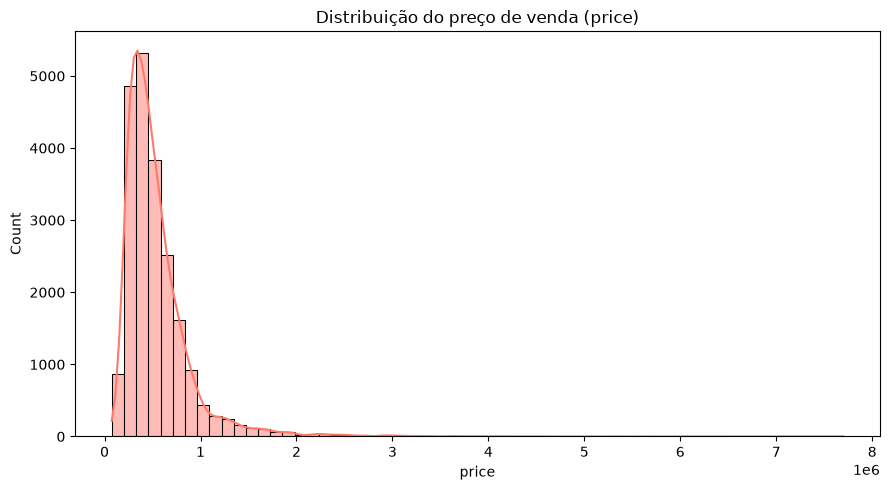

<Figure size 640x480 with 0 Axes>

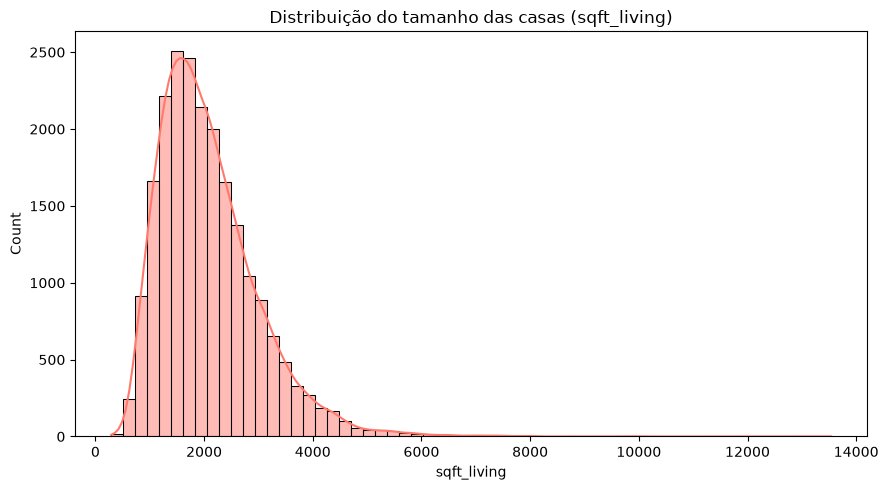

<Figure size 640x480 with 0 Axes>

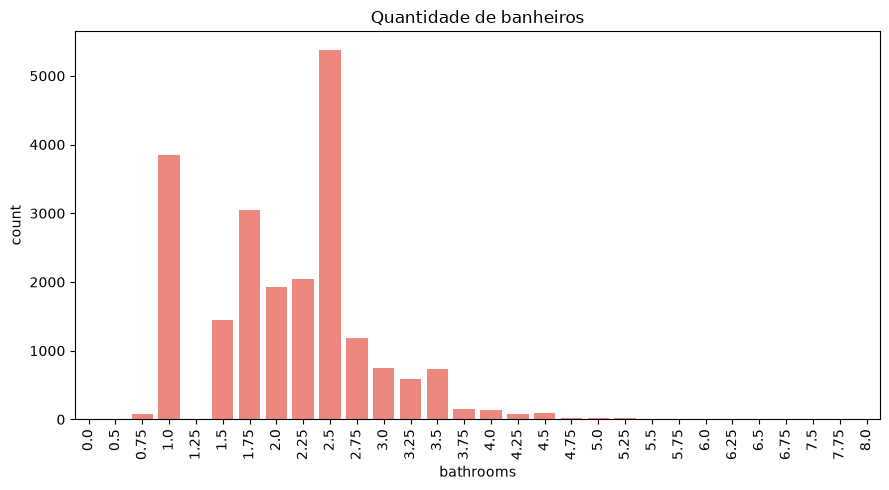

Assimetria (skew) de price: 4.02
Mediana: US$ 450,000   |   Média: US$ 540,085


In [14]:
#Cria pasta para salvar os gráficos como figuras

FIGURES_DIR = Path('outputs/figures')
#Função para salvar as figuras
def _savefig(filename: str) -> None:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(FIGURES_DIR / filename, bbox_inches='tight', dpi=150)
#Função para criar um histograma
def plot_histogram(serie: pd.Series, titulo: str, filename: str) -> None:
    """Histograma com curva de densidade (KDE) de uma variável numérica."""
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(serie, bins=60, kde=True, ax=ax, color="#FF796c")
    ax.set_title(titulo)
    plt.tight_layout()
    _savefig(filename)
    plt.show()
#Função grafico de barras
def plot_countplot(df: pd.DataFrame, x_col: str, titulo: str, filename: str) -> None:
    """Countplot para variáveis categóricas, com título e salvamento."""
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.countplot(data=df, x=x_col, ax=ax, color="#FF796c")
    ax.set_title(titulo)
    plt.xticks(rotation=90)
    plt.tight_layout()
    _savefig(filename)
    plt.show()

plot_histogram(df["price"], "Distribuição do preço de venda (price)", "01_distribuicao_price.png")
plt.subplots_adjust()
plot_histogram(df["sqft_living"], "Distribuição do tamanho das casas (sqft_living)", "02_distribuicao_sqft_living.png")
plt.subplots_adjust()
plot_countplot(df, 'bathrooms', "Quantidade de banheiros", "03_quantidade_bathrooms.png")
# Conforme podemos notar temos uma curva assimetrica a direita devido a maioria das casas terem preços similares e poucas casas com preços elevados que elevam a média.
# Esta curva também é representada no gráfico de preço x tamanho da casas
# A plotagem de quantidade de banheiros 
print(f"Assimetria (skew) de price: {df['price'].skew():.2f}")
print(f"Mediana: US$ {df['price'].median():,.0f}   |   Média: US$ {df['price'].mean():,.0f}")

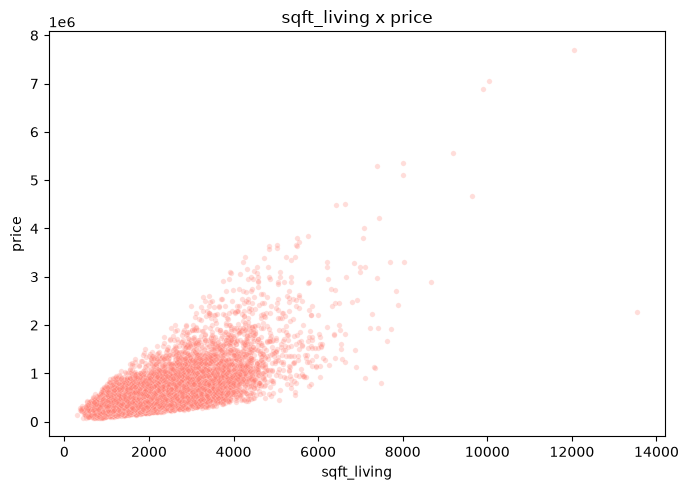

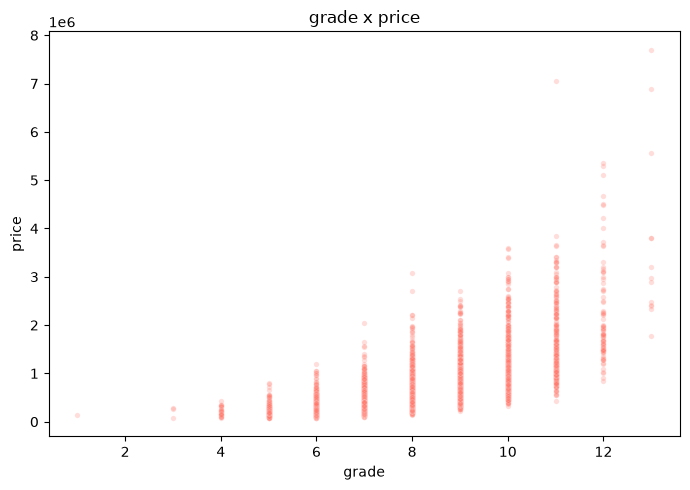

In [15]:
#Gráfico de dispersão, quando os pontos estiverem aderentes a reta de relação linear podemos dizer que a relação seria forte
def plot_scatter(df: pd.DataFrame, x: str, y: str, filename: str) -> None:
    """Dispersão entre duas variáveis numéricas."""
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=df, x=x, y=y, alpha=0.25, s=15, ax=ax, color="#FF796c")
    ax.set_title(f"{x} x {y}")
    plt.tight_layout()
    _savefig(filename)
    plt.show()

plot_scatter(df, x="sqft_living", y="price", filename="03_scatter_sqftliving_price.png")
plot_scatter(df, x="grade", y="price", filename="03b_scatter_grade_price.png")

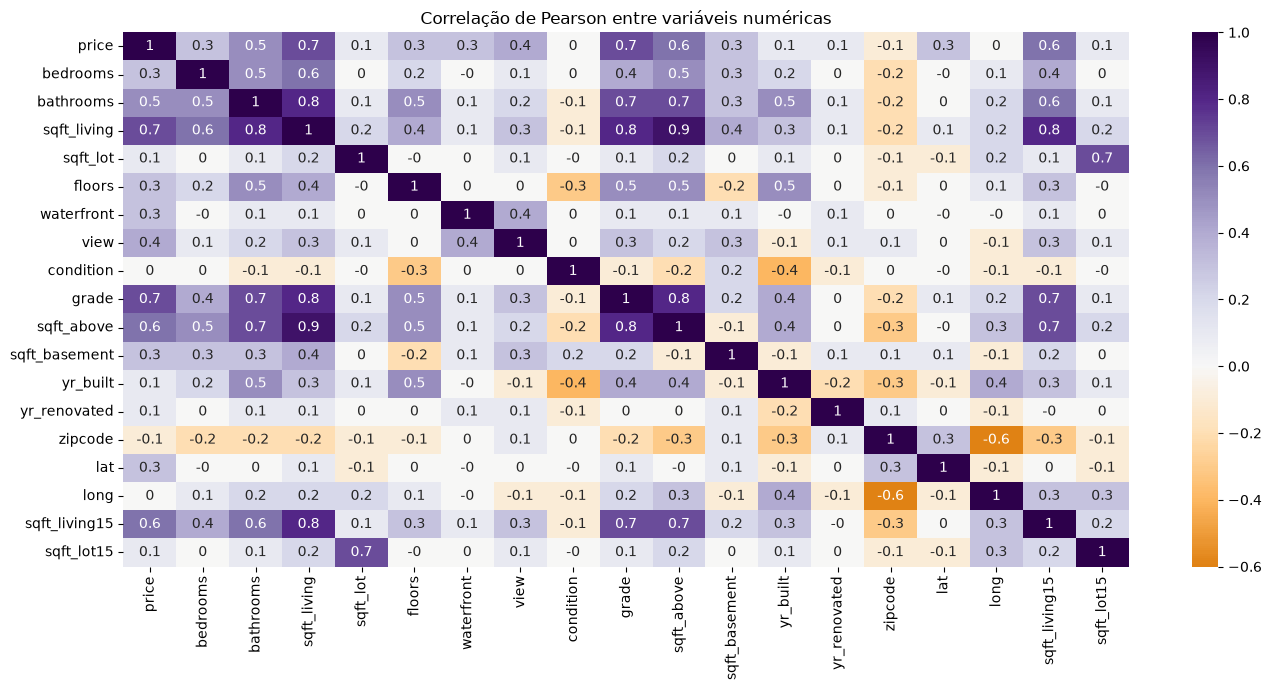


 Pares com correlação > 0.7:
sqft_living  sqft_above       0.876644
             grade            0.762727
             sqft_living15    0.756440
grade        sqft_above       0.755924
bathrooms    sqft_living      0.754684
sqft_above   sqft_living15    0.731871
sqft_lot     sqft_lot15       0.718556
grade        sqft_living15    0.713197
price        sqft_living      0.702055
dtype: float64

 Correlação de todas as colunas com o preço:


id              -0.016742
price            1.000000
bedrooms         0.308366
bathrooms        0.525150
sqft_living      0.702055
sqft_lot         0.089661
floors           0.256814
waterfront       0.266371
view             0.397299
condition        0.036379
grade            0.667434
sqft_above       0.605567
sqft_basement    0.323842
yr_built         0.054006
yr_renovated     0.126436
zipcode         -0.053182
lat              0.307010
long             0.021613
sqft_living15    0.585377
sqft_lot15       0.082448
Name: price, dtype: float64

In [16]:
#Função para a criação da matriz de corelação, utilizado o método de Pearson 
def plot_correlation_heatmap(df: pd.DataFrame, filename: str) -> None:
    """Mapa de calor de correlação de Pearson entre variáveis numéricas."""
    corr = df.select_dtypes(include=np.number).corr().round(1)
    fig, ax = plt.subplots(figsize=(14, 7))
    sns.heatmap(corr, annot = True, cmap="PuOr", center=0, ax=ax)
    ax.set_title("Correlação de Pearson entre variáveis numéricas")
    plt.tight_layout()
    _savefig(filename)
    plt.show()


num_cols = df.select_dtypes(include=np.number).drop(columns=["id"]).columns
plot_correlation_heatmap(df[num_cols], filename="02_correlation_heatmap.png")

corr = df[num_cols].corr()

#Vamos utilizar a matriz de correlação para identificar pares de variáveis com correlação acima de 0,7,
#pois você vai notar que muitas delas apresentam forte relação entre si. Poderíamos adotar limites mais rígidos,
#como 0,8 ou 0,9, mas isso reduziria bastante a quantidade de pares detectados neste conjunto específico.
print("\n Pares com correlação > 0.7:")
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(pairs[pairs.abs() > 0.7].sort_values(ascending=False))
#Correlação de todas as colunas com o preço
print("\n Correlação de todas as colunas com o preço:")
df.corr(numeric_only=True)['price']

Análise: Pelos gráficos plotados podemos notar que a maioria dos imóveis esta abaixo do valor de US$1.000.000,00. As colunas sqft_living e grade apresentam relação com a coluna de preço, além da coluna sqft_living15.

Fase 2 - Tratamento e limpeza

In [17]:
# Linhas duplicadas: duplicatas completas (já removidas anteriormente mas estamos nos certificando) ---
n_duplicatas = df.duplicated().sum()
print(f"Duplicatas completas encontradas: {n_duplicatas}")

#  Duplicatas do mesmo imovel mais com id diferente (Neste caso foram verificados os imoveis com mais de uma venda no período analisado,
#Contudo não foram excluídos)
n_id_dup = df.duplicated(subset=["id"]).sum()
print(f"\nRegistros com 'id' repetido: {n_id_dup}")
exemplo = df[df.duplicated(subset=["id"], keep=False)].sort_values("id")[["id", "date", "price"]].head(10)
print("\nExemplo de um mesmo imóvel com duas vendas:")
print(exemplo)

Duplicatas completas encontradas: 0

Registros com 'id' repetido: 177

Exemplo de um mesmo imóvel com duas vendas:
              id             date     price
2496     1000102  20140916T000000  280000.0
2497     1000102  20150422T000000  300000.0
16814    7200179  20141016T000000  150000.0
16815    7200179  20150424T000000  175000.0
11433  109200390  20140820T000000  245000.0
11434  109200390  20141020T000000  250000.0
12417  123039336  20140611T000000  148000.0
12418  123039336  20141208T000000  244900.0
7792   251300110  20140731T000000  225000.0
7793   251300110  20150114T000000  358000.0


In [18]:
# Valores ausentes (verificação de valores ausentes, contudo se fez a exclusão dos mesmos na etapa de carregamento dos dados)
print("Valores ausentes por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nAssimetria (skew) de sqft_above: {df['sqft_above'].skew():.2f}")

Valores ausentes por coluna:
Series([], dtype: int64)

Assimetria (skew) de sqft_above: 1.45


In [19]:
#Função para a remoção de duplicadas completas, caso haveria seria imputados valores pela mediana 
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Remove duplicatas completas e imputa 'sqft_above' ausente pela mediana."""
    df = df.drop_duplicates()
    df["sqft_above"] = df["sqft_above"].fillna(df["sqft_above"].median())
    return df.reset_index(drop=True)
df = clean_data(df)

print("Duplicatas completas restantes:", df.duplicated().sum())
print("Valores ausentes restantes:", df.isnull().sum().sum())

Duplicatas completas restantes: 0
Valores ausentes restantes: 0


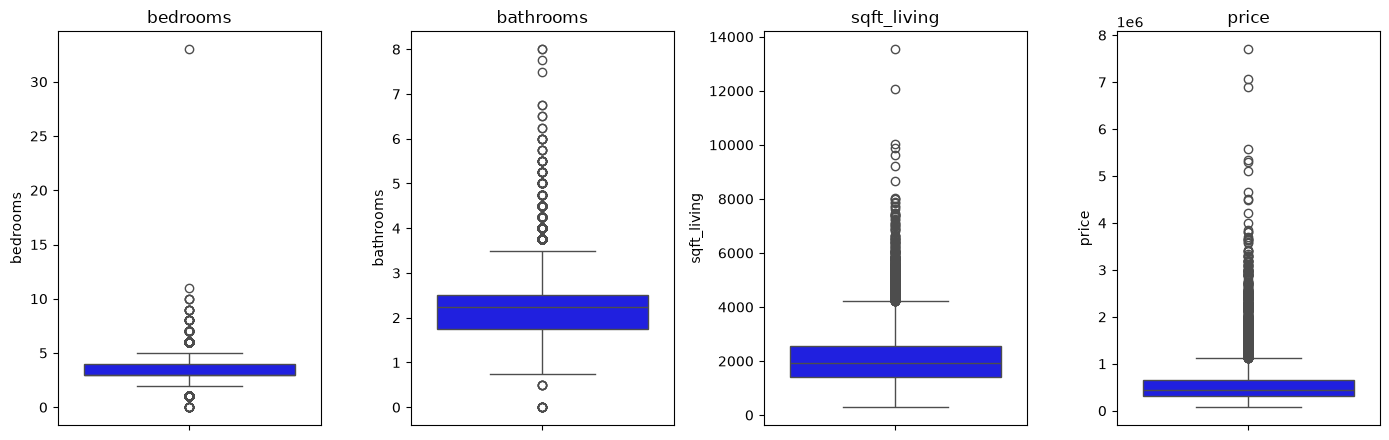

               id  bedrooms  bathrooms  sqft_living      price
15868  2402100895        33       1.75         1620   640000.0
8755   1773100755        11       3.00         3000   520000.0
15159  5566100170        10       2.00         3610   650000.0
19252  8812401450        10       3.00         2920   660000.0
13312   627300145        10       5.25         4590  1148000.0


In [20]:
#Função para a verificação de outliers 
def plot_boxplots(df: pd.DataFrame, cols: list[str], filename: str) -> None:
    """Um boxplot por coluna, lado a lado - útil para inspeção visual de outliers."""
    fig, axes = plt.subplots(1, len(cols), figsize=(3.5 * len(cols), 4.5))
    for ax, col in zip(axes, cols):
        sns.boxplot(y=df[col], ax=ax, color="#0000ff")
        ax.set_title(col)
    plt.tight_layout()
    _savefig(filename)
    plt.show()

plot_boxplots(df, ["bedrooms", "bathrooms", "sqft_living", "price"], filename="04_boxplots_outliers.png")

# Suspeita: um imóvel com número de quartos muito fora do padrão
print(df.sort_values("bedrooms", ascending=False)[["id", "bedrooms", "bathrooms", "sqft_living", "price"]].head(5))

Após analisar o boxplot vimos que temos um imóvel com 33 quartos e com valor não condizente, o tamanho do imóvel era pequeno para este número de quartos e o número de banheiro também seria pequeno. Esta linha será tratada com Winsorização por IQR

In [21]:
#Função de aplicação da Winsorização por IQR
def cap_iqr(serie: pd.Series, fator: float = 1.5) -> pd.Series:
    """Winsorização por IQR: valores fora de [Q1 - fator*IQR, Q3 + fator*IQR]
    são limitados (capped) ao limite mais próximo, em vez de removidos."""
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - fator * iqr, q3 + fator * iqr
    return serie.clip(limite_inf, limite_sup)
print("Tratamento de outliers em 'bedrooms':")
q1, q3 = df["bedrooms"].quantile(0.25), df["bedrooms"].quantile(0.75)
iqr = q3 - q1
limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = ((df["bedrooms"] < limite_inf) | (df["bedrooms"] > limite_sup)).sum()
print(f"  limite=[{limite_inf:.1f}, {limite_sup:.1f}]  outliers tratados={outliers}")

df["bedrooms"] = cap_iqr(df["bedrooms"])
print("\nNovo máximo de bedrooms:", df["bedrooms"].max())

Tratamento de outliers em 'bedrooms':
  limite=[1.5, 5.5]  outliers tratados=546

Novo máximo de bedrooms: 5.5


Fase 3 - Feature engineering

In [22]:
#Função para criação das colunas derivadas da Fase 3: ano_venda, idade_imovel, foi_reformado e preco_por_m2.
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Cria as colunas derivadas da Fase 3: ano_venda,
    idade_imovel, foi_reformado e preco_por_m2 (esta última só para leitura -
    nunca deve entrar como variável preditora, pois deriva diretamente de 'price')."""
    df = df.copy()
    df["ano_venda"] = pd.to_datetime(df["date"].str[:8], format="%Y%m%d").dt.year
    df["idade_imovel"] = df["ano_venda"] - df["yr_built"]
    df["foi_reformado"] = (df["yr_renovated"] > 0).astype(int)
    df["preco_por_m2"] = df["price"] / df["sqft_living"]
    return df

df = add_features(df)

print(df[["date", "yr_built", "idade_imovel", "yr_renovated", "foi_reformado",
          "price", "sqft_living", "preco_por_m2"]].head())

              date  yr_built  idade_imovel  yr_renovated  foi_reformado  \
0  20141013T000000      1955            59             0              0   
1  20141209T000000      1951            63          1991              1   
2  20150225T000000      1933            82             0              0   
3  20141209T000000      1965            49             0              0   
4  20150218T000000      1987            28             0              0   

      price  sqft_living  preco_por_m2  
0  221900.0         1180    188.050847  
1  538000.0         2570    209.338521  
2  180000.0          770    233.766234  
3  604000.0         1960    308.163265  
4  510000.0         1680    303.571429  


In [23]:
# Define os locais para a gravação do date frame
PROCESSED_DIR = Path('data/processed')
PROCESSED_FILE = PROCESSED_DIR / 'kc_house_data_processed.csv'
#Função para o processo de gravação 
def save_processed_data(df: pd.DataFrame) -> None:
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(PROCESSED_FILE, index=False)
    print(f"Dataset processado salvo em: {PROCESSED_FILE}")
save_processed_data(df)

Dataset processado salvo em: data\processed\kc_house_data_processed.csv


Fase 4 : Preparação para a modelagem

In [25]:
# Conjunto de variáveis explicativas/preditoras que vamos usar (não precisamos incluir id, date, price e preco_por_m2).
explicativas = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront",
              "view", "condition", "grade", "sqft_above", "sqft_basement", "sqft_living15",
              "sqft_lot15", "idade_imovel", "foi_reformado", "lat", "long", "zipcode"]

X = df[explicativas].copy()
y = df["price"].copy()

# Divisão treino/teste (70/30), feita antes do encoding de zipcode para evitar vazamento.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Treino: {X_train.shape}   Teste: {X_test.shape}")

Treino: (15127, 18)   Teste: (6484, 18)


In [27]:
# Salva o dataframe final usado na modelagem: apenas as variáveis

# Define o local de salvamento
FINAL_DIR = Path('data/final')
FINAL_FILE = FINAL_DIR / 'kc_house_data_final.csv'
#Função para salvar o dataframe
def save_final_data(df: pd.DataFrame) -> None:
    """Salva em data/final/ apenas as colunas usadas na modelagem (Fase 4)."""
    FINAL_DIR.mkdir(parents=True, exist_ok=True)
    df.to_csv(FINAL_FILE, index=False)
    print(f"Dataset final salvo em: {FINAL_FILE}")
def select_final_columns(df: pd.DataFrame, feature_cols: list[str], target_col: str) -> pd.DataFrame:
    """Seleciona apenas as variáveis explicativas e o alvo: o recorte de
    colunas que efetivamente entra na modelagem (Fase 4)."""
    return df[feature_cols + [target_col]].copy()

df_final = select_final_columns(df, explicativas, "price")
save_final_data(df_final)

Dataset final salvo em: data\final\kc_house_data_final.csv


In [37]:
# Re-initialize X_train and X_test to ensure 'zipcode' column is present
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 1. Aplica a tradução em ambos os conjuntos

# Preço médio de venda por zipcode, calculado SOMENTE com o conjunto de treino.
preco_medio_por_zip = y_train.groupby(X_train["zipcode"]).mean()

#  divide os zipcodes em 10 grupos de tamanho aproximadamente igual
faixa_zip = pd.qcut(preco_medio_por_zip, 10, labels=[f"faixa_{i}" for i in range(10)], duplicates="drop")

# mapa_zip é um dicionário {zipcode: faixa}
mapa_zip = faixa_zip.to_dict()

# faixa_mais_comum é uma resposta padrão para zipcodes desconhecidos no teste
faixa_mais_comum = faixa_zip.mode()[0]

X_train['zipcode_faixa'] = X_train['zipcode'].map(mapa_zip)
X_test['zipcode_faixa'] = X_test['zipcode'].map(mapa_zip).fillna(faixa_mais_comum)

# Convert to category dtype before accessing .cat accessor
X_train['zipcode_faixa'] = X_train['zipcode_faixa'].astype('category')
X_test['zipcode_faixa'] = X_test['zipcode_faixa'].astype('category')

# Garante que o teste tenha exatamente o mesmo tipo categórico do treino
# Isso fixa a ordem das categorias e evita o bug do drop_first individual
X_test['zipcode_faixa'] = pd.Categorical(X_test['zipcode_faixa'], categories=X_train['zipcode_faixa'].cat.categories)

print("Zipcodes do teste sem correspondência no treino:", X_test['zipcode'].map(mapa_zip).isna().sum())

# 2. Remove a coluna original e faz o One-Hot Encoding
X_train_encoded = pd.get_dummies(X_train.drop(columns=['zipcode']), columns=['zipcode_faixa'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test.drop(columns=['zipcode']), columns=['zipcode_faixa'], drop_first=True)

# 3. Alinha as colunas por segurança
X_train = X_train_encoded
X_test = X_test_encoded.reindex(columns=X_train.columns, fill_value=0)

print(f"\nQuantidade de variáveis explicativas após o encoding: {X_train.shape[1]}")




Zipcodes do teste sem correspondência no treino: 0

Quantidade de variáveis explicativas após o encoding: 26


In [38]:
# Correlação entre as próprias variáveis explicativas com a intenção de identificar multicolinearidade
corr_x = X_train.corr(numeric_only=True)
pares_redundantes = corr_x.where(np.triu(np.ones(corr_x.shape), k=1).astype(bool)).stack()
print("Pares de variáveis explicativas com correlação > 0.7:")
print(pares_redundantes[pares_redundantes.abs() > 0.7].sort_values(ascending=False))

Pares de variáveis explicativas com correlação > 0.7:
sqft_living  sqft_above       0.875957
             grade            0.757279
             sqft_living15    0.754754
bathrooms    sqft_living      0.753842
grade        sqft_above       0.751981
sqft_above   sqft_living15    0.728808
grade        sqft_living15    0.709011
dtype: float64


In [39]:
colunas_redundantes = ["sqft_above", "sqft_living15", "sqft_lot15"]
X_train = X_train.drop(columns=colunas_redundantes).astype(float)
X_test = X_test.drop(columns=colunas_redundantes).astype(float)

# Cálculo do VIF (Fator de Inflação da Variância). É preciso adicionar uma
# constante (intercepto) antes de calcular o VIF - sem ela, variáveis que não
# passam perto de zero (como lat/long) recebem um VIF artificialmente enorme.
X_vif = sm.add_constant(X_train)
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=X_vif.columns,
).drop("const")
print("VIF por variável (valores acima de 10 indicam multicolinearidade relevante):")
print(vif.sort_values(ascending=False))

VIF por variável (valores acima de 10 indicam multicolinearidade relevante):
sqft_living              5.167300
zipcode_faixa_faixa_7    4.118515
zipcode_faixa_faixa_6    4.027024
zipcode_faixa_faixa_8    3.906399
zipcode_faixa_faixa_5    3.690419
zipcode_faixa_faixa_3    3.497548
grade                    3.368671
bathrooms                3.334598
lat                      3.067504
zipcode_faixa_faixa_4    2.892424
zipcode_faixa_faixa_9    2.724317
idade_imovel             2.588306
zipcode_faixa_faixa_2    2.472275
zipcode_faixa_faixa_1    2.143171
floors                   2.080448
sqft_basement            1.981779
long                     1.707972
bedrooms                 1.705101
view                     1.410998
condition                1.240818
waterfront               1.217550
foi_reformado            1.142340
sqft_lot                 1.108066
dtype: float64


Temos valores abaixo de 10, contudo a um resultado entre 5 e 10 que merece um monitoramento caso o  modelo apresente instabilidade, foram removidas 3 colunas redundantes nesta etapa

In [40]:
# Escalonamento: para a Regressão Linear, o escalonamento não é obrigatório
# para a qualidade da predição, mas ajuda a comparar a magnitude dos coeficientes
# entre variáveis com escalas muito diferentes
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Total de variaveis explicativas/features utilizadas no modelo:", X_train.shape[1])
print(list(X_train.columns))

Total de variaveis explicativas/features utilizadas no modelo: 23
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'idade_imovel', 'foi_reformado', 'lat', 'long', 'zipcode_faixa_faixa_1', 'zipcode_faixa_faixa_2', 'zipcode_faixa_faixa_3', 'zipcode_faixa_faixa_4', 'zipcode_faixa_faixa_5', 'zipcode_faixa_faixa_6', 'zipcode_faixa_faixa_7', 'zipcode_faixa_faixa_8', 'zipcode_faixa_faixa_9']


Com a padronização todos os coeficientes ficam na mesma escala, facilitando a interpretação do modelo

Fase 5 - Modelagem, validação e diagnósticode Overfitting